## K-Means for Color Compression

Outcome of this project: 
1. Give you a worked example of K-means on non-synthetic data
2. Reinforce your understanding of K-means' underlying theory by demonstrating its affect when applied to a photograph

## Objective:
Here we will be using the pixels of a photograph of some tulips based on their encoded color values. We will explore how different values of _k_ affect the clustering of the pixels, and thus the appearance of the photograph with the help of K-means

In [4]:
pip install plotly

   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------- ----------------------------- 3.9/14.8 MB 32.1 MB/s eta 0:00:01
   ---------------------------------------  14.7/14.8 MB 49.9 MB/s eta 0:00:01
   ---------------------------------------- 14.8/14.8 MB 43.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd

%pylab inline
import plotly.graph_objects as go

from sklearn.cluster import KMeans

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [15]:
img = plt.imread('using_kmeans_for_color_compression_tulips_photo.jpeg')

(320, 240, 3)


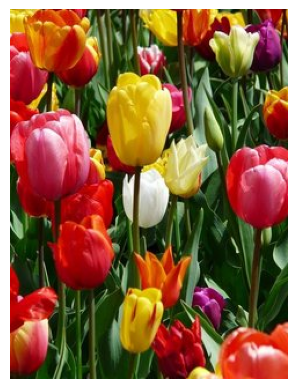

In [16]:
print(img.shape)
plt.imshow(img)
plt.axis('off');

Info from the image: The shape is 320 x 240 x 3, meaning 320 vertical pixels and 240 horizontal pixels and 3 is the encode the color of each pixel -- meaning 3 parameters: red, green and blue (RGB values)

So each color—R, G, and B—the encoded value can range from 0-255. This means that there are 256³, or 16,777,216 different combinations of RGB, each resulting in a unique color on your screen.

In [17]:
#reshaping the image
img_flat = img.reshape(img.shape[0]*img.shape[1], 3)
img_flat[:5, :]

array([[211, 197,  38],
       [199, 181,  21],
       [178, 154,   0],
       [185, 152,   0],
       [184, 145,   0]], dtype=uint8)

In [18]:
img_flat.shape

(76800, 3)

## Plotting the data in 3-D space

In [19]:
img_flat_df = pd.DataFrame(img_flat, columns = ['r', 'g', 'b'])
img_flat_df.head()

,r,g,b
0,211,197,38
1,199,181,21
2,178,154,0
3,185,152,0
4,184,145,0


**Note:** The following cell's output is viewable in two ways: You can re-run this cell, or manually convert the notebook to "Trusted." 

In [25]:
!pip install --upgrade nbformat


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import nbformat
print(nbformat.__version__)

5.10.4


In [28]:
# Create 3D plot where each pixel in the `img` is displayed in its actual color
trace = go.Scatter3d(x = img_flat_df.r,
                     y = img_flat_df.g,
                     z = img_flat_df.b,
                     mode='markers',
                     marker=dict(size=1,
                                 color=['rgb({},{},{})'.format(r,g,b) for r,g,b 
                                        in zip(img_flat_df.r.values, 
                                               img_flat_df.g.values, 
                                               img_flat_df.b.values)],
                                 opacity=0.5))

data = [trace]

layout = go.Layout(margin=dict(l=0,
                               r=0,
                               b=0,
                               t=0),
                               )

fig = go.Figure(data=data, layout=layout)
fig.update_layout(scene = dict(
                    xaxis_title='R',
                    yaxis_title='G',
                    zaxis_title='B'),
                  )
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed